# Test combining MCS masks over time with idealized data
### This notebook demonstrates generating synthetic MCS mask for testing the combine function.
- Create cloud-like masks using Gaussian filters
- Create unique track numbers for the masks to mimic MCS pixel-level mask data
- Test combine mask function
- Visualize the results

### Author: 
- Zhe Feng <zhe.feng@pnnl.gov>


In [1]:
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

### 1.  Prepare Parameters

In [2]:
# Parameters
domain_size = (200, 150)  # (y, x) - flipped from original (150, 200)
timesteps = 24

# Cloud parameters
# Define the parameters for each cloud in a dictionary
clouds = [
    {
        'name': 'Cloud 1',
        'initial_center_x': domain_size[1] // 5,  # Changed from domain_size[0]
        # 'initial_center_y': domain_size[0] // 4 * 3,  # Changed from domain_size[1]
        'initial_center_y': domain_size[0] // 4 * 2.5,  # Changed from domain_size[1]
        'dx': 1,  # Initial movement direction in x (1 for right, -1 for left)
        'dy': 0,  # Initial movement direction in y (1 for up, -1 for down)
        'move_x': domain_size[1] // (timesteps * 1.5),  # Changed from domain_size[0]
        'move_y': 0,
        'sigma_tb_min': 0.15, # Minimum sigma for Tb Gaussian (initial cloud size)
        'sigma_tb_max': 10,       # Maximum sigma for Tb Gaussian (maximum cloud size)
        'amplitude_tb_min': 0.05,  # Initial amplitude of Tb Gaussian (initial intensity)
        'amplitude_tb_max': 1.0,   # Maximum amplitude of Tb Gaussian (peak intensity)
        'sigma_pr_min': 0.05,    # Minimum sigma for pr Gaussian (initial precipitation area size)
        'sigma_pr_max': 10,       # Maximum sigma for pr Gaussian (maximum precipitation area size)
        'amplitude_pr_min': 0.5,   # Initial amplitude of pr Gaussian (initial precipitation intensity)
        'amplitude_pr_max': 1.0,   # Maximum amplitude of pr Gaussian (peak precipitation intensity)
    },
    {
        'name': 'Cloud 2',
        'initial_center_x': domain_size[1] // 5,  # Changed from domain_size[0]
        # 'initial_center_y': domain_size[0] // 4 * 2,  # Changed from domain_size[1]
        'initial_center_y': domain_size[0] // 4 * 1.5,  # Changed from domain_size[1]
        'dx': 1,  # Moves left
        'dy': 0,  # Moves down
        'move_x': domain_size[1] // (timesteps * 1.5),  # Changed from domain_size[0]
        'move_y': 0,
        'sigma_tb_min': 0.15,
        'sigma_tb_max': 12,
        'amplitude_tb_min': 0.05,
        'amplitude_tb_max': 1.0,
        'sigma_pr_min': 0.05,
        'sigma_pr_max': 12,
        'amplitude_pr_min': 0.5,
        'amplitude_pr_max': 1.0,
    },
    {
        'name': 'Cloud 3',
        'initial_center_x': domain_size[1] // 5,  # Changed from domain_size[0]
        'initial_center_y': domain_size[0] // 4,  # Changed from domain_size[1]
        # 'initial_center_y': domain_size[0] // 4 * 2,  # Changed from domain_size[1]
        'dx': 1,  # Moves left
        'dy': 0,  # Moves down
        'move_x': domain_size[1] // (timesteps * 1.5),  # Changed from domain_size[0]
        'move_y': 0,
        'sigma_tb_min': 0.15,
        'sigma_tb_max': 6,
        'amplitude_tb_min': 0.05,
        'amplitude_tb_max': 1.0,
        'sigma_pr_min': 0.05,
        'sigma_pr_max': 6,
        'amplitude_pr_min': 0.5,
        'amplitude_pr_max': 1.0,
    },
]

# Other parameters
growth_timestep = 15   # Timestep at which the cloud reaches maximum size and intensity

tb_exponent = 3        # Exponent for shaping Tb profile (controls sharpness of temperature gradient)
pr_exponent = 1        # Exponent for shaping pr profile (controls precipitation rate distribution)
pr_max = 20            # Maximum precipitation rate (mm/hr)

In [3]:
domain_size[0] // 4 * 3, domain_size[0] // 4 * 2.5, domain_size[0] // 4 * 2

(150, 125.0, 100)

In [4]:
domain_size[0] // 4 * 2.5, domain_size[0] // 4 * 1.5, domain_size[0] // 4

(125.0, 75.0, 50)

### 2. Create Clouds

This section generates synthetic clouds using Gaussian filters or other methods. The clouds are created as 2D arrays with varying intensity and size.

In [5]:
# Generate a meshgrid for the domain
y = np.linspace(0, domain_size[0] - 1, domain_size[0])  # y comes from domain_size[0]
x = np.linspace(0, domain_size[1] - 1, domain_size[1])  # x comes from domain_size[1]
x_grid, y_grid = np.meshgrid(x, y)

# Function to create a circular Gaussian distribution
def create_gaussian(center_x, center_y, sigma_x, sigma_y, amplitude):
    gauss = amplitude * np.exp(-(((x_grid - center_x) ** 2) / (2 * sigma_x ** 2) +
                                 ((y_grid - center_y) ** 2) / (2 * sigma_y ** 2)))
    return gauss

# Initialize data arrays
Tb = np.full((timesteps, domain_size[0], domain_size[1]), 300.0)
pr = np.zeros((timesteps, domain_size[0], domain_size[1]))   

# Initialize clouds
for cloud in clouds:
    # Initialize current positions
    cloud['center_x'] = cloud['initial_center_x']
    cloud['center_y'] = cloud['initial_center_y']
    # Initialize lists to store center positions over time for visualization
    cloud['center_positions_x'] = []
    cloud['center_positions_y'] = []
    # Define buffer to prevent cloud from touching edges
    cloud['buffer_tb'] = cloud['sigma_tb_max'] * 3
    # Define boundaries for the center positions
    cloud['min_center_x'] = cloud['buffer_tb']
    cloud['max_center_x'] = domain_size[1] - cloud['buffer_tb']
    cloud['min_center_y'] = cloud['buffer_tb']
    cloud['max_center_y'] = domain_size[0] - cloud['buffer_tb']

# Main simulation loop
for t in range(timesteps):
    # Calculate the growth factor f(t)
    if t <= growth_timestep:
        f = t / growth_timestep
    else:
        f = (timesteps - t - 1) / (timesteps - growth_timestep - 1)

    # Initialize lists to store normalized Tb and pr for combining
    tb_normalized_list = []
    pr_normalized_list = []

    # Update each cloud
    for cloud in clouds:
        # Adjust sigma and amplitude using f(t)
        sigma_tb = cloud['sigma_tb_min'] + f * (cloud['sigma_tb_max'] - cloud['sigma_tb_min'])
        amplitude_tb = cloud['amplitude_tb_min'] + f * (cloud['amplitude_tb_max'] - cloud['amplitude_tb_min'])
        sigma_pr = cloud['sigma_pr_min'] + f * (cloud['sigma_pr_max'] - cloud['sigma_pr_min'])
        amplitude_pr = cloud['amplitude_pr_min'] + f * (cloud['amplitude_pr_max'] - cloud['amplitude_pr_min'])

        # Adjust Gaussian properties for Tb
        tb_gaussian = create_gaussian(cloud['center_x'], cloud['center_y'],
                                      sigma_x=sigma_tb, sigma_y=sigma_tb, amplitude=amplitude_tb)
        tb_gaussian_filtered = gaussian_filter(tb_gaussian, sigma=2)
        tb_normalized = tb_gaussian_filtered / np.max(tb_gaussian_filtered)
        tb_normalized_list.append(tb_normalized)

        # Adjust Gaussian properties for pr
        pr_gaussian = create_gaussian(cloud['center_x'], cloud['center_y'],
                                      sigma_x=sigma_pr, sigma_y=sigma_pr, amplitude=amplitude_pr)
        pr_gaussian_filtered = gaussian_filter(pr_gaussian, sigma=2)
        pr_normalized = pr_gaussian_filtered / np.max(pr_gaussian_filtered)
        pr_normalized_list.append(pr_normalized)

        # Store center positions for visualization
        cloud['center_positions_x'].append(cloud['center_x'])
        cloud['center_positions_y'].append(cloud['center_y'])

        # Move the Gaussian center for next timestep
        cloud['center_x'] += cloud['dx'] * cloud['move_x']
        cloud['center_y'] += cloud['dy'] * cloud['move_y']

        # Check for boundary collisions and reverse direction if necessary
        if cloud['center_x'] >= cloud['max_center_x']:
            cloud['center_x'] = cloud['max_center_x']
            cloud['dx'] *= -1
        elif cloud['center_x'] <= cloud['min_center_x']:
            cloud['center_x'] = cloud['min_center_x']
            cloud['dx'] *= -1
        if cloud['center_y'] >= cloud['max_center_y']:
            cloud['center_y'] = cloud['max_center_y']
            cloud['dy'] *= -1
        elif cloud['center_y'] <= cloud['min_center_y']:
            cloud['center_y'] = cloud['min_center_y']
            cloud['dy'] *= -1

    # Combine Tb from all clouds, taking the minimum (coldest temperature) at each point
    Tb_combined = np.full((domain_size[0], domain_size[1]), 300.0)
    for tb_normalized in tb_normalized_list:
        Tb_core = 220 + (13 * (1 - tb_normalized) ** tb_exponent)
        Tb_core = np.clip(Tb_core, 220, 240)
        Tb_combined = np.minimum(Tb_combined, np.where(tb_normalized > 0.01, Tb_core, 300.0))
    Tb[t] = Tb_combined

    # Combine pr from all clouds, summing the precipitation rates
    pr_combined = np.zeros((domain_size[0], domain_size[1]))
    for pr_normalized in pr_normalized_list:
        pr_scaled = pr_max * pr_normalized ** pr_exponent
        pr_threshold = 0.001
        pr_field = np.where(pr_normalized > pr_threshold, pr_scaled, 0.0)
        pr_combined += pr_field
    pr[t] = pr_combined



### 2b. Create Track Number Arrays

This section generates track number arrays where each blob is assigned a constant integer ID (1, 2, 3) throughout its lifecycle.

In [6]:
# Initialize track number array (time, y, x)
tracknumber = np.zeros((timesteps, domain_size[0], domain_size[1]), dtype=int)

# Reset cloud positions to initial values for track number generation
for cloud in clouds:
    cloud['center_x'] = cloud['initial_center_x']
    cloud['center_y'] = cloud['initial_center_y']

# Main simulation loop for track numbers
for t in range(timesteps):
    # Calculate the growth factor f(t) - same as before
    if t <= growth_timestep:
        f = t / growth_timestep
    else:
        f = (timesteps - t - 1) / (timesteps - growth_timestep - 1)

    # Update each cloud and assign track numbers
    for idx, cloud in enumerate(clouds):
        # Track number for this cloud (1, 2, 3, ...)
        track_id = idx + 1
        
        # Adjust sigma using f(t) - use tb parameters to define blob size
        sigma_tb = cloud['sigma_tb_min'] + f * (cloud['sigma_tb_max'] - cloud['sigma_tb_min'])
        amplitude_tb = cloud['amplitude_tb_min'] + f * (cloud['amplitude_tb_max'] - cloud['amplitude_tb_min'])
        
        # Create Gaussian to define the blob extent
        tb_gaussian = create_gaussian(cloud['center_x'], cloud['center_y'],
                                      sigma_x=sigma_tb, sigma_y=sigma_tb, amplitude=amplitude_tb)
        tb_gaussian_filtered = gaussian_filter(tb_gaussian, sigma=2)
        tb_normalized = tb_gaussian_filtered / np.max(tb_gaussian_filtered)
        
        # Create a mask where the blob exists (threshold at 0.01 like in Tb)
        blob_mask = tb_normalized > 0.01
        
        # Assign track number to this blob
        # Use maximum to handle potential overlaps (later track numbers will overwrite)
        tracknumber[t] = np.where(blob_mask, track_id, tracknumber[t])
        
        # Move the Gaussian center for next timestep
        cloud['center_x'] += cloud['dx'] * cloud['move_x']
        cloud['center_y'] += cloud['dy'] * cloud['move_y']
        
        # Check for boundary collisions and reverse direction if necessary
        if cloud['center_x'] >= cloud['max_center_x']:
            cloud['center_x'] = cloud['max_center_x']
            cloud['dx'] *= -1
        elif cloud['center_x'] <= cloud['min_center_x']:
            cloud['center_x'] = cloud['min_center_x']
            cloud['dx'] *= -1
        if cloud['center_y'] >= cloud['max_center_y']:
            cloud['center_y'] = cloud['max_center_y']
            cloud['dy'] *= -1
        elif cloud['center_y'] <= cloud['min_center_y']:
            cloud['center_y'] = cloud['min_center_y']
            cloud['dy'] *= -1

In [7]:
# Check the shape of track number array
print(f"Track number array shape: {tracknumber.shape}")
print(f"Unique track numbers: {np.unique(tracknumber)}")
print(f"Track number data type: {tracknumber.dtype}")

Track number array shape: (24, 200, 150)
Unique track numbers: [0 1 2 3]
Track number data type: int64


### 2c. Visualize Track Numbers

This section visualizes the track number arrays at different timesteps.

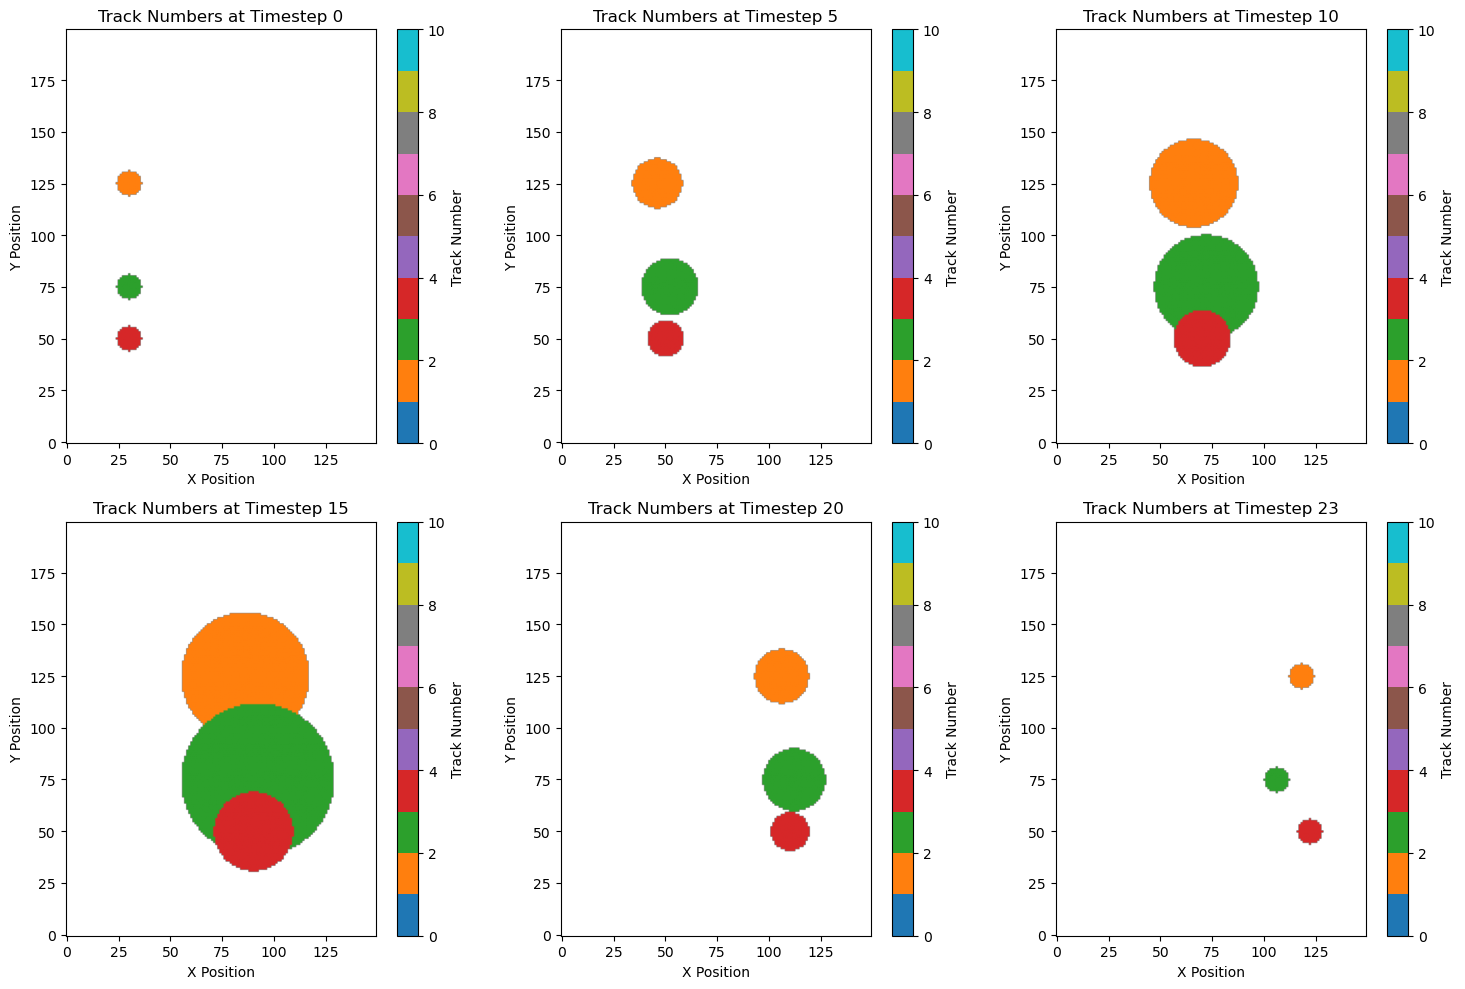

In [8]:
# Visualize track numbers at selected timesteps
timesteps_to_plot = [0, 5, 10, 15, 20, timesteps - 1]  # Example timesteps

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, timestep in enumerate(timesteps_to_plot):
    ax = axes[i]
    Zm = np.ma.masked_where(tracknumber[timestep]==0, tracknumber[timestep])
    im = ax.imshow(Zm, cmap='tab10', origin='lower', vmin=0, vmax=10)
    ax.set_title(f'Track Numbers at Timestep {timestep}')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    plt.colorbar(im, ax=ax, label='Track Number')

plt.tight_layout()
plt.show()

### 2d. Create Track Swaths Function

This section creates a function to generate track swaths and coverage counts from track number arrays.

In [9]:
def create_track_swaths_and_coverage(tracknumber):
    """
    Create track swaths and coverage count arrays from a 3D track number array.
    
    Parameters:
    -----------
    tracknumber : numpy.ndarray
        3D array with dimensions (time, y, x) containing track numbers at each timestep.
        Background/no-track pixels should be 0.
    
    Returns:
    --------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values.
        Each swath shows all pixels covered by that track (labeled with track_id).
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values.
        Each array shows the number of timesteps each pixel was covered by that track.
    
    Example:
    --------
    >>> tracknumber = np.zeros((24, 200, 150), dtype=int)
    >>> # ... populate tracknumber with track data ...
    >>> swaths, coverage = create_track_swaths_and_coverage(tracknumber)
    """
    # Get unique track numbers (excluding 0 which is background)
    unique_tracks = np.unique(tracknumber)
    unique_tracks = unique_tracks[unique_tracks > 0]
    
    # Initialize dictionaries
    track_swaths_dict = {}
    track_coverage_dict = {}
    
    # Process each unique track using vectorized operations
    for track_id in unique_tracks:
        # Create binary mask for this track across all timesteps
        track_mask = (tracknumber == track_id).astype(int)
        
        # Track swath: all pixels covered by this track labeled with track number
        swath = np.any(track_mask, axis=0).astype(int) * track_id
        track_swaths_dict[track_id] = swath
        
        # Coverage count: number of times each pixel is covered
        coverage = np.sum(track_mask, axis=0)
        track_coverage_dict[track_id] = coverage
    
    return track_swaths_dict, track_coverage_dict

In [10]:
# Apply the function to create track swaths and coverage
track_swaths_dict, track_coverage_dict = create_track_swaths_and_coverage(tracknumber)

# Get unique track numbers for reference
unique_tracks = np.unique(tracknumber)
unique_tracks = unique_tracks[unique_tracks > 0]

print(f"Unique tracks: {unique_tracks}")

# Calculate combined arrays for visualization
track_swath = np.zeros((domain_size[0], domain_size[1]), dtype=int)
track_coverage = np.zeros((domain_size[0], domain_size[1]), dtype=int)

for track_id in unique_tracks:
    swath = track_swaths_dict[track_id]
    coverage = track_coverage_dict[track_id]
    track_swath = np.where(swath > 0, track_id, track_swath)
    track_coverage += coverage

print(f"\nTrack swath shape: {track_swath.shape}")
print(f"Track coverage shape: {track_coverage.shape}")
print(f"Max coverage count: {np.max(track_coverage)}")

# Display summary for each track
for track_id in unique_tracks:
    swath_pixels = np.sum(track_swaths_dict[track_id] > 0)
    max_coverage = np.max(track_coverage_dict[track_id])
    print(f"Track {track_id}: {swath_pixels} pixels in swath, max coverage = {max_coverage} timesteps")

Unique tracks: [1 2 3]

Track swath shape: (200, 150)
Track coverage shape: (200, 150)
Max coverage count: 13
Track 1: 3589 pixels in swath, max coverage = 11 timesteps
Track 2: 4574 pixels in swath, max coverage = 13 timesteps
Track 3: 2353 pixels in swath, max coverage = 8 timesteps


In [11]:
track_swaths_dict[np.int64(1)].shape

(200, 150)

In [12]:
track_swath.shape

(200, 150)

### 2e. Visualize Track Swaths

This section visualizes the swath for each unique track.

In [13]:
# # Visualize track swaths in a 1x3 panel
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for i, track_id in enumerate(unique_tracks):
#     ax = axes[i]
    
#     # Get swath for this track
#     swath = track_swaths_dict[track_id]
    
#     # Mask zero values for better visualization
#     swath_masked = np.ma.masked_where(swath == 0, swath)
    
#     # Plot the swath
#     im = ax.imshow(swath_masked, cmap='tab10', origin='lower', vmin=0, vmax=10)
#     ax.set_title(f'Track {track_id} Swath\n({np.sum(swath > 0)} pixels)')
#     ax.set_xlabel('X Position')
#     ax.set_ylabel('Y Position')
#     plt.colorbar(im, ax=ax, label='Track Number')

# plt.tight_layout()
# plt.show()

# # Also visualize coverage counts for each track
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# for i, track_id in enumerate(unique_tracks):
#     ax = axes[i]
    
#     # Get coverage for this track
#     coverage = track_coverage_dict[track_id]
    
#     # Mask zero values for better visualization
#     coverage_masked = np.ma.masked_where(coverage == 0, coverage)
    
#     # Plot the coverage count
#     im = ax.imshow(coverage_masked, cmap='YlOrRd', origin='lower')
#     ax.set_title(f'Track {track_id} Coverage Count\n(max = {np.max(coverage)} timesteps)')
#     ax.set_xlabel('X Position')
#     ax.set_ylabel('Y Position')
#     plt.colorbar(im, ax=ax, label='Number of Timesteps')

# plt.tight_layout()
# plt.show()

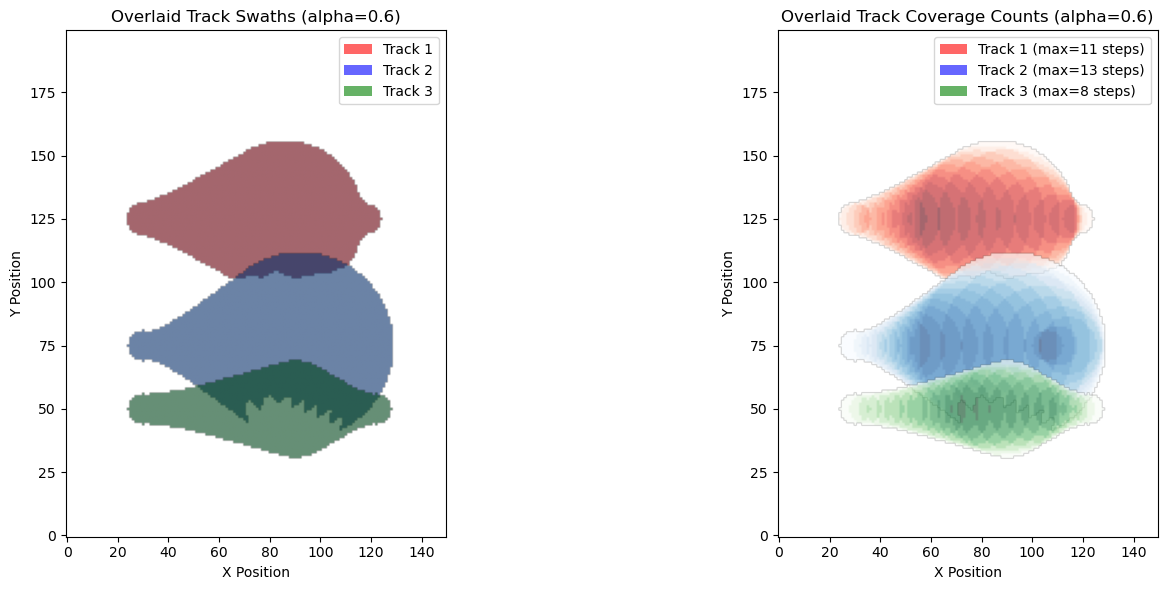

In [14]:
# Overlay all swaths and coverage counts in a 1x2 panel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Overlay all track swaths
ax = axes[0]
colors = ['Reds', 'Blues', 'Greens']  # Different colormaps for each track
for i, track_id in enumerate(unique_tracks):
    swath = track_swaths_dict[track_id]
    # Create binary mask and plot with transparency
    swath_binary = (swath > 0).astype(float)
    swath_masked = np.ma.masked_where(swath_binary == 0, swath_binary)
    ax.imshow(swath_masked, cmap=colors[i], origin='lower', alpha=0.6, vmin=0, vmax=1)

ax.set_title('Overlaid Track Swaths (alpha=0.6)')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')

# Add a custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.6, label='Track 1'),
                   Patch(facecolor='blue', alpha=0.6, label='Track 2'),
                   Patch(facecolor='green', alpha=0.6, label='Track 3')]
ax.legend(handles=legend_elements, loc='best')

# Panel 2: Overlay all track coverage counts
ax = axes[1]
colormaps = ['Reds', 'Blues', 'Greens']  # Different colormaps for each track
for i, track_id in enumerate(unique_tracks):
    coverage = track_coverage_dict[track_id]
    # Mask zero values and plot with transparency
    coverage_masked = np.ma.masked_where(coverage == 0, coverage)
    im = ax.imshow(coverage_masked, cmap=colormaps[i], origin='lower', alpha=0.6)

ax.set_title('Overlaid Track Coverage Counts (alpha=0.6)')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')

# Add a custom legend with max coverage info
legend_elements = [Patch(facecolor='red', alpha=0.6, 
                         label=f'Track 1 (max={np.max(track_coverage_dict[1])} steps)'),
                   Patch(facecolor='blue', alpha=0.6, 
                         label=f'Track 2 (max={np.max(track_coverage_dict[2])} steps)'),
                   Patch(facecolor='green', alpha=0.6, 
                         label=f'Track 3 (max={np.max(track_coverage_dict[3])} steps)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

### 2f. Combine Swaths with Overlap Resolution

This section creates a function to combine all track swaths into a single 2D array, resolving overlaps by assigning the track number with the largest coverage count.

In [15]:
def combine_swaths_with_priority(track_swaths_dict, track_coverage_dict):
    """
    Combine multiple track swaths into a single 2D array, resolving overlaps
    by assigning the track number with the largest coverage count.
    
    Parameters:
    -----------
    track_swaths_dict : dict
        Dictionary with track_id as keys and 2D swath arrays as values
    track_coverage_dict : dict
        Dictionary with track_id as keys and 2D coverage count arrays as values
    
    Returns:
    --------
    combined_swath : numpy.ndarray
        2D array with combined swaths, where overlapping pixels are assigned
        to the track with the highest coverage count
    """
    # Get the shape from the first swath
    first_key = list(track_swaths_dict.keys())[0]
    shape = track_swaths_dict[first_key].shape
    
    # Initialize output array
    combined_swath = np.zeros(shape, dtype=int)
    
    # Initialize array to track maximum coverage at each pixel
    max_coverage = np.zeros(shape, dtype=int)
    
    # Process each track using vectorized operations
    for track_id in track_swaths_dict.keys():
        # Get swath and coverage for this track
        swath = track_swaths_dict[track_id]
        coverage = track_coverage_dict[track_id]
        
        # Create mask for pixels belonging to this track's swath
        track_mask = swath > 0
        
        # Update combined_swath where:
        # 1. Current pixel has no assignment yet (combined_swath == 0), OR
        # 2. Current track has higher coverage than previous assignment
        update_mask = track_mask & ((combined_swath == 0) | (coverage > max_coverage))
        
        # Apply updates using vectorized operations
        combined_swath = np.where(update_mask, track_id, combined_swath)
        max_coverage = np.where(update_mask, coverage, max_coverage)
    
    return combined_swath

In [16]:
# Apply the function to combine all swaths
combined_swath = combine_swaths_with_priority(track_swaths_dict, track_coverage_dict)

# Print summary statistics
print(f"Combined swath shape: {combined_swath.shape}")
print(f"Unique track numbers in combined swath: {np.unique(combined_swath)}")
print(f"Total pixels assigned: {np.sum(combined_swath > 0)}")

# Count pixels per track in the combined swath
for track_id in unique_tracks:
    pixel_count = np.sum(combined_swath == track_id)
    print(f"Track {track_id}: {pixel_count} pixels in combined swath")

Combined swath shape: (200, 150)
Unique track numbers in combined swath: [0 1 2 3]
Total pixels assigned: 9288
Track 1: 3485 pixels in combined swath
Track 2: 3735 pixels in combined swath
Track 3: 2068 pixels in combined swath


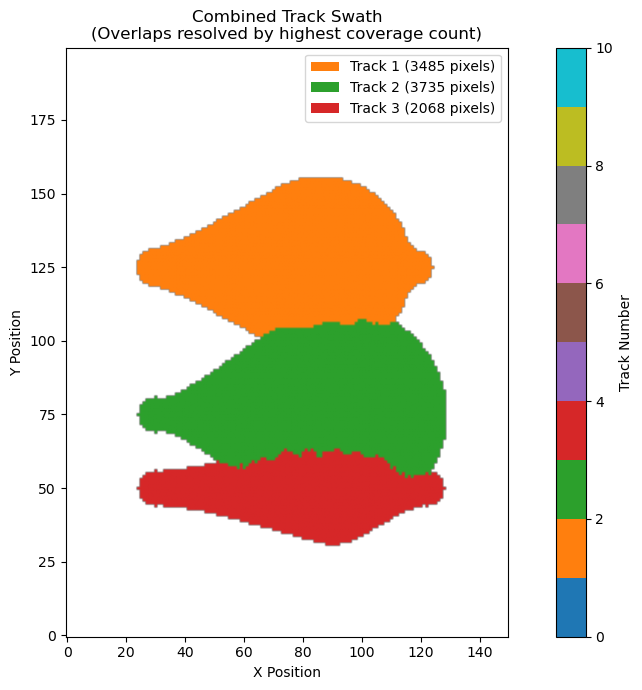

In [17]:
# Visualize the combined swath
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Mask zero values for better visualization
combined_swath_masked = np.ma.masked_where(combined_swath == 0, combined_swath)

# Plot the combined swath
im = ax.imshow(combined_swath_masked, cmap='tab10', origin='lower', vmin=0, vmax=10)
ax.set_title('Combined Track Swath\n(Overlaps resolved by highest coverage count)')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
cbar = plt.colorbar(im, ax=ax, label='Track Number')

# Add legend showing pixel counts
from matplotlib.patches import Patch
legend_elements = []
for track_id in unique_tracks:
    pixel_count = np.sum(combined_swath == track_id)
    legend_elements.append(Patch(facecolor=plt.cm.tab10(track_id/10), 
                                 label=f'Track {track_id} ({pixel_count} pixels)'))
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()